In [1]:
from spm_agent.mcp.spm_mcp_client import SPMMCPClient

from langgraph.graph import StateGraph, START, END

from spm_agent.nodes.microscope_get_status_node import get_status_node
from spm_agent.nodes.scanner_calibration_node import get_scanner_calibrations_node

from spm_agent.states.pfm_experiment_state import PFMExperimentState

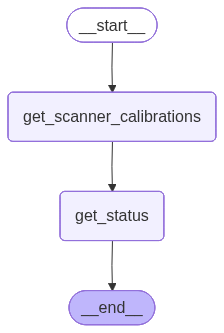

In [2]:
builder = StateGraph(PFMExperimentState)
builder.add_node('get_scanner_calibrations', get_scanner_calibrations_node)
builder.add_node('get_status', get_status_node)

builder.add_edge(START, 'get_scanner_calibrations')
builder.add_edge('get_scanner_calibrations', 'get_status')
builder.add_edge('get_status', END)

graph = builder.compile()
graph

In [3]:
result = await graph.ainvoke({})

In [4]:
result

{'instrument_state': InstrumentState(scan_settings=ScanSettings(x_scan_center_m=2.5987729e-06, y_scan_center_m=3.1991781e-06, scan_size_m=1e-06, pixels=256, scan_rate_hz=0.49920127), probe_position=ProbePosition(x_m=2.598772900000001e-06, y_m=3.1991780999999996e-06), pfm_excitation=PFMExcitation(drive_amplitude_v=0.5, drive_frequency_hz=382335.22, dart_width_hz=10000.0), contact_feedback=ContactFeedback(setpoint_v=1.0, gain=50.0)),
 'scanner_calibrations': ScannerCalibrations(x_scanner_offset_m=-1.797207841304832e-05, y_scanner_offset_m=1.554795964604318e-05, x_lvdt_sens_m_per_v=9.2639584e-06, y_lvdt_sens_m_per_v=9.9031586e-06)}

In [5]:
sc_cal = result['scanner_calibrations']
sc_cal.x_scanner_offset_m, sc_cal.y_scanner_offset_m

(-1.797207841304832e-05, 1.554795964604318e-05)

In [6]:
spm_client = SPMMCPClient()
tools = await spm_client.get_tools()

In [7]:
for t in tools:
    if t.name == "pfm_run_dart_pfm_scan":            # "pfm_get_experiment_status", ...
        #print(t.description)     # ← your docstring, verbatim
        print(t.args_schema)     # JSON Schema of parameters

{'additionalProperties': False, 'properties': {'scan_size_m': {'default': None, 'title': 'Scan Size M'}, 'n_points': {'default': None, 'title': 'N Points'}, 'scan_rate_hz': {'default': None, 'title': 'Scan Rate Hz'}, 'tune_probe': {'default': True, 'title': 'Tune Probe'}}, 'type': 'object'}


In [ ]:
r = await spm_client.call_tool("pfm_move_tip", )

In [10]:
r = await spm_client.call_tool("pfm_run_dart_pfm_scan", {'scan_size_m': 1e-6, 'n_points': 128, 'scan_rate_hz': .5, 'tune_probe': True})

In [11]:
r

[{'type': 'text',
  'text': '{"ok":true,"data":{"path":"C:\\\\Users\\\\Asylum User\\\\Documents\\\\Asylum Research Data\\\\260707\\\\PLZT\\\\PLZT_0009.ibw","ScanSize":1e-6,"PointsLines":256,"ScanRate":2.0032051,"x_scan_center_m":2.5987729e-6,"y_scan_center_m":3.1991781e-6,"tuned":true},"audit":{"ts_unix":1783548409.0836906,"request_id":"a52d5a55-4718-459b-956f-3dd7574ab23a","instrument_id":"asylum-aespm","tool":"pfm.run_dart_pfm_scan","operator_id":null,"config_snapshot":{}}}',
  'id': 'lc_29fe8725-6164-4a11-861c-242bed712988'}]